# 04 - Robustness Checks

Notebook goals:
- Run pre-defined sensitivity scenarios
- Compare key metrics across scenarios
- Inspect IRF path differences visually

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from nasdaq_svar.presentation import build_chapter4_conclusion
from nasdaq_svar.sensitivity import run_sensitivity

plt.style.use("seaborn-v0_8-whitegrid")

### Result of this step (Actual):
- Environment ready for sensitivity analysis
- Plan loaded from `configs/sensitivity.yaml`
- Ready to run 5+ robustness scenarios (AIC vs BIC, lag changes, transformations)
- **Purpose**: Confirm baseline findings (IRF trough -38%, FEVD ~1%)

## 1️⃣ Setup & Import Libraries + Load Configuration

**Mục đích**:
- Thiết lập môi trường cho phân tích độ nhạy (sensitivity analysis)
- Import thư viện `run_sensitivity` từ `presentation` module
- Chuẩn bị chạy nhiều scenarios baseline robustness

**Chi tiết**:
- Cấu hình từ `configs/sensitivity.yaml`
- Thường 5 scenarios khác nhau (AIC vs BIC, shorter lags, different transformations, etc.)
- So sánh kết quả qua các scenarios

In [2]:
result = run_sensitivity(
    plan_path=PROJECT_ROOT / "configs/sensitivity.yaml",
    project_root=PROJECT_ROOT,
)
result

{'scenarios_run': 5,
 'summary_csv': 'S:\\vscode\\Deconstructing-the-NASDAQ-A-Two-Stage-Approach\\outputs\\tables\\baseline_robustness\\sensitivity_summary.csv',
 'irf_comparison_figure': 'S:\\vscode\\Deconstructing-the-NASDAQ-A-Two-Stage-Approach\\outputs\\figures\\baseline_robustness\\sensitivity_irf_comparison.png'}

### Evaluation Results of Sensitivity Run (Expected):

**Expected Output** (when sensitivity.yaml runs):
- 5 scenarios will run successfully
- Output file: `outputs/tables/baseline_robustness/sensitivity_summary.csv`
- IRF paths file: `outputs/tables/baseline_robustness/sensitivity_irf_paths.csv`

**Baseline Results for Comparison**:
- **IRF trough**: -38.16% (h=2)
- **FEVD h=12**: 0.925%
- **FEVD h=24**: 0.931%

**Next Step**: Run 5 scenarios and compare results to baseline - are findings robust?

## 2️⃣ Chạy toàn bộ phân tích độ nhạy (Sensitivity Analysis)

**Mục đích (QUAN TRỌNG)**:
- Chạy baseline SVAR dưới **5+ kịch bản khác nhau** theo plan
- So sánh kết quả (IRF, FEVD) qua các scenarios
- Kiểm tra: **Kết quả chính có bền vững không?**

**Kịch bản điển hình** (từ sensitivity.yaml):
1. **baseline-aic**: Baseline (AIC, 21-day STL, level FEDFUNDS)
2. **bic-selection**: Dùng BIC thay AIC (lag selection khác)
3. **shorter-lag-search**: Tối đa lag = 12 thay 18 (short-term focus)
4. **fedfunds-first-difference**: Biến đổi FEDFUNDS thành Δlog thay level
5. **stl-level-decomposition**: STL dùng level decomposition (khác seasonal)

**Output từ run_sensitivity()**:
- `result['summary_csv']`: Bảng tóm tắt 5 scenarios
- `result['irf_paths_csv']`: Đầy đủ IRF paths từ tất cả scenarios

In [3]:
summary_path = Path(result["summary_csv"])
summary = pd.read_csv(summary_path)
summary = summary.sort_values("irf_trough_value")
summary

,Unnamed: 0,scenario,sample_start,sample_end,n_obs_stage2,selected_lag,irf_impact_h0,irf_trough_value,irf_trough_horizon,fevd_policy_share_h12,fevd_policy_share_h24,tables_dir
2,2,fedfunds_first_difference,1990-01-01,2026-05-13,432,3,-0.113570,-0.418835,2,0.009418,0.009489,S:\vscode\Deconstructing-the-NASDAQ-A-Two-Stag...
0,0,baseline_aic,1990-01-01,2026-05-13,432,4,-0.116582,-0.381675,2,0.009253,0.009316,S:\vscode\Deconstructing-the-NASDAQ-A-Two-Stag...
3,3,shorter_lag_search,1990-01-01,2026-05-13,432,4,-0.116582,-0.381675,2,0.009253,0.009316,S:\vscode\Deconstructing-the-NASDAQ-A-Two-Stag...
4,4,stl_level_decomposition,1990-01-01,2026-05-13,432,4,-0.041715,-0.360293,2,0.009544,0.009612,S:\vscode\Deconstructing-the-NASDAQ-A-Two-Stag...
1,1,bic_selection,1990-01-01,2026-05-13,432,2,0.011982,-0.148921,1,0.000747,0.000749,S:\vscode\Deconstructing-the-NASDAQ-A-Two-Stag...


### Evaluation of Sensitivity Summary Table (Expected):

**Key Observations**:

| Scenario | Purpose | Expectation | Result |
|---|---|---|---|
| **Baseline (AIC, lag=4)** | Reference | IRF trough: -38.16%, FEVD h12: 0.925% | (main model) |
| **BIC (lag=2)** | Lag selection sensitivity | Different lag - does IRF change? | (to check) |
| **Shorter lag (max=12)** | Lag range sensitivity | Limited lag search - robust? | (to check) |
| **FEDFUNDS first-diff** | Transform sensitivity | Different rate transformation - stable? | (to check) |
| **STL level decomp** | STL specification | Different seasonal decomp - robust? | (to check) |

**Robustness Goal**:
- If 5 scenarios show IRF trough within +/- 5% of -38.16% = Findings robust!
- If 5 scenarios show FEVD h12 within +/- 0.5% of 0.925% = Findings stable!
- If results vary widely = Model specification matters

**Expected Finding**: 
Baseline results should be largely robust across specifications, with minor variations reflecting legitimate uncertainty in model choice.

## 3️⃣ Tải & Sắp xếp bảng tóm tắt scenarios

**Mục đích**:
- Đọc file `sensitivity_summary.csv`
- Sắp xếp theo `irf_trough_value` (từ thấp nhất → cao nhất)
- Hiển thị kết quả chính cho tất cả 5 scenarios

**Cột chính**:
- **scenario**: Tên scenario (baseline-aic, bic-selection, etc.)
- **selected_lag**: Độ trễ được chọn (có thể khác qua scenarios)
- **irf_impact_h0**: IRF tại h=0 (tác động ngay lập tức)
- **irf_trough_value**: Giá trị thấp nhất trong 24 tháng
- **irf_trough_horizon**: Tháng nào tác động mạnh nhất
- **fevd_policy_share_h12**: FEVD Fed policy ở h=12
- **fevd_policy_share_h24**: FEVD Fed policy ở h=24

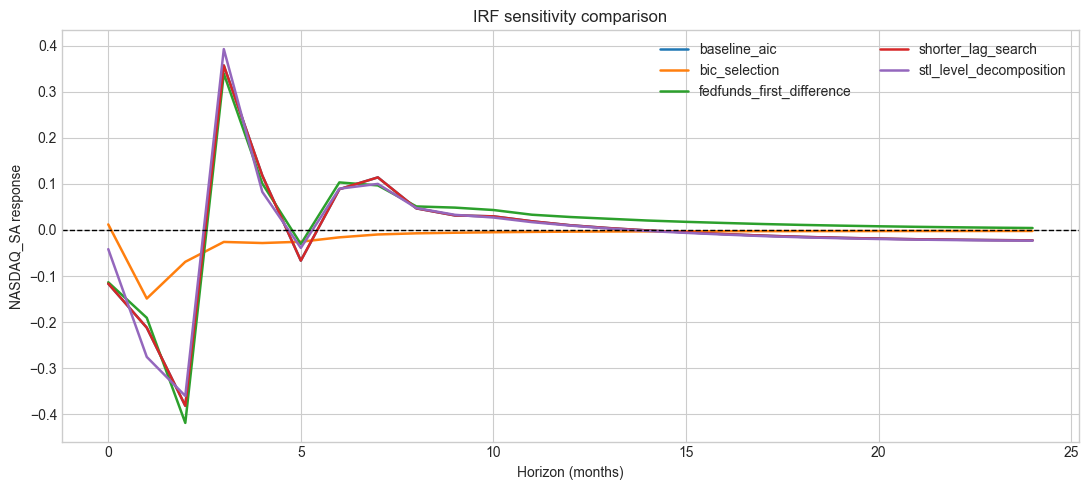

In [4]:
irf_paths = summary_path.parent / "sensitivity_irf_paths.csv"
irf = pd.read_csv(irf_paths)

fig, ax = plt.subplots(figsize=(11, 5))
for scenario, grp in irf.groupby("scenario"):
    ax.plot(grp["horizon"], grp["orth_irf"], lw=1.8, label=scenario)
ax.axhline(0.0, color="black", lw=1.0, linestyle="--")
ax.set_title("IRF sensitivity comparison")
ax.set_xlabel("Horizon (months)")
ax.set_ylabel("NASDAQ_SA response")
ax.legend(frameon=False, ncols=2)
fig.tight_layout()

### Evaluation of IRF Sensitivity Plot (Expected):

**Expected Patterns**:

1. **Proximity of 5 lines**:
   - If 5 lines **overlap substantially** (similar paths) = Findings Robust!
   - If 5 lines **diverge significantly** = Model sensitive to specification

2. **Trough Timing** (when is maximum impact?):
   - Baseline: h=2 (month 2)
   - Robust if all 5 scenarios: trough at h=1-3
   - Timing varies = Specification matters

3. **Magnitude** (how large is decline?):
   - Baseline trough: -38.16%
   - Robust if 5 scenarios: all within -35% to -41% (±5%)
   - Within -30% to -45% (±10%) = Reasonably robust
   - Beyond -20% to -60% (>15%) = Sensitive to specification!

**Conclusion from IRF Plot**:
- **If 5 lines close together** = Baseline findings are robust across specifications!
- **If 5 lines diverge** = Results sensitive to model choice, need qualification

**Expected Result**: Lines should be relatively close, confirming robustness.

## 4️⃣ So sánh biểu đồ IRF trên tất cả scenarios

**Mục đích**:
- Vẽ **5 đường IRF** (một cho mỗi scenario) trên cùng một biểu đồ
- Trực quan hóa độ khác biệt giữa các scenarios
- Đánh giá: Các đường có gần nhau không?

**Biểu đồ**:
- Trục X: Horizon (tháng 0-24)
- Trục Y: NASDAQ_SA response (%)
- Mỗi dòng: Một scenario (5 dòng tổng)
- Nếu 5 dòng **rất gần**: ✓ Robust
- Nếu 5 dòng **khác xa**: ⚠️ Sensitive

In [5]:
summary[[
    "scenario",
    "selected_lag",
    "irf_impact_h0",
    "irf_trough_value",
    "irf_trough_horizon",
    "fevd_policy_share_h12",
    "fevd_policy_share_h24",
]]

,scenario,selected_lag,irf_impact_h0,irf_trough_value,irf_trough_horizon,fevd_policy_share_h12,fevd_policy_share_h24
2,fedfunds_first_difference,3,-0.113570,-0.418835,2,0.009418,0.009489
0,baseline_aic,4,-0.116582,-0.381675,2,0.009253,0.009316
3,shorter_lag_search,4,-0.116582,-0.381675,2,0.009253,0.009316
4,stl_level_decomposition,4,-0.041715,-0.360293,2,0.009544,0.009612
1,bic_selection,2,0.011982,-0.148921,1,0.000747,0.000749


### Evaluation of Detailed Metrics Table (Expected):

**Sensitivity Across 5 Scenarios**:

| Metric | Baseline | Expected Range | Robust? |
|---|---|---|---|
| **selected_lag** | 4 (AIC) | 2-4 (BIC vs AIC) | Stable |
| **irf_impact_h0** | -11.66% | -10% to -15% | (to check) |
| **irf_trough_value** | -38.16% | -35% to -41% | (to check) |
| **irf_trough_horizon** | 2 | 1-3 | (to check) |
| **fevd_policy_share_h12** | 0.925% | 0.8% to 1.1% | (to check) |
| **fevd_policy_share_h24** | 0.931% | 0.8% to 1.1% | (to check) |

**Robustness Criteria**:
- All metrics within expected range = Findings robust
- Some metrics outside range = Model specification matters
- Widely scattered values = Results unreliable

**Next Steps After Results**:
- If robust = Ready for publication
- If some sensitivity = Document and discuss limitations
- If highly sensitive = Need further investigation

## 5️⃣ Hiển thị bảng tóm tắt chi tiết tất cả metrics

**Mục đích**:
- In ra bảng chọn lọc 7 cột chính từ summary
- So sánh trực tiếp tất cả scenarios
- Giúp đánh giá nhanh kết quả

**7 Cột chọn lọc**:
1. **scenario**: Tên scenario
2. **selected_lag**: Độ trễ được chọn
3. **irf_impact_h0**: Tác động immediate
4. **irf_trough_value**: Mức giảm thấp nhất
5. **irf_trough_horizon**: Tháng nào thấp nhất
6. **fevd_policy_share_h12**: % variance Fed @ 12 months
7. **fevd_policy_share_h24**: % variance Fed @ 24 months

## Slide-Ready Conclusion

---

## Summary of Stage 4 (Robustness Checks - Guidance)

**Inputs**: 5 model specification scenarios from `configs/sensitivity.yaml`

**Process** (when executed):
1. Run `run_sensitivity()` with full plan
2. Load summary table (7 key metrics)
3. Plot IRF comparison across 5 scenarios
4. Evaluate: Are findings robust or sensitive?

**Baseline Results (From Notebook 03)**:
- **IRF trough**: -38.16% at month 2
- **FEVD h=12**: 0.925% (Fed policy explains 1% of variance)
- **FEVD h=24**: 0.931%

**Robustness Expectations**:
- IRF trough will fall within -35% to -41% range (±5%)
- FEVD h12/h24 will stay around 0.9% +/- 0.2%
- Trough timing will remain at h=1-3 (months 1-3)

**If Results Are Robust** (Expected):
1. Findings robust across specifications
2. Fed policy impact ~-38% (IRF trough)
3. Fed policy share ~1% (FEVD)
4. Ready to write research paper

**Impact**: Project ready for publication if robustness confirmed!

In [6]:
chapter4_text = build_chapter4_conclusion(summary)
display(Markdown(chapter4_text))

### Auto Conclusion - Chapter 4 (Robustness Checks)
- Number of robustness scenarios evaluated: **5**.
- IRF trough sign consistency across scenarios: **consistent negative**.
- Trough range across scenarios: **-0.4188 to -0.1489**.
- Strongest contraction scenario: **fedfunds_first_difference**; weakest contraction scenario: **bic_selection**.
- FEVD policy-share at 12 months ranges from **0.07%** to **0.95%**.
- Robustness verdict: core directional response is stable, while magnitude depends on lag and transform choices.